# One question, one chart

A chart is a sentence you can see. Before you choose a color or a chart type, write the question down.

North Lab finished jobs on five weekdays. Four people:

| Person | Mon | Tue | Wed | Thu | Fri |
|---|---:|---:|---:|---:|---:|
| Ada | 4 | 5 | 5 | 6 | 7 |
| Grace | 6 | 6 | 7 | 7 | 8 |
| Alan | 3 | 4 | 4 | 5 | 4 |
| Linus | 5 | 5 | 6 | 6 | 7 |

Two questions use this same table and must not share a picture.

1. Who finished the most jobs this week?
2. Did the lab speed up from Monday to Friday?

The habit for every lesson is short:

1. Ask one question.
2. Compute the number that answers it.
3. Draw that number as position, length, or color.
4. Say the sentence the chart supports.
5. Name one way a careless reading would go wrong.


## The numbers, before any picture

Weekly totals:

$$
\begin{aligned}
\text{Ada} &= 4+5+5+6+7 = 27 \\
\text{Grace} &= 6+6+7+7+8 = 34 \\
\text{Alan} &= 3+4+4+5+4 = 20 \\
\text{Linus} &= 5+5+6+6+7 = 29
\end{aligned}
$$

Grace finished the most. Alan finished the fewest. The four totals add to

$$
27+34+20+29 = 110
$$

Daily totals, reading down the columns:

$$
\begin{aligned}
\text{Mon} &= 4+6+3+5 = 18 \\
\text{Tue} &= 5+6+4+5 = 20 \\
\text{Wed} &= 5+7+4+6 = 22 \\
\text{Thu} &= 6+7+5+6 = 24 \\
\text{Fri} &= 7+8+4+7 = 26
\end{aligned}
$$

Each day is exactly two jobs above the day before. The lab did speed up, and the size of the speedup is $2$ jobs per day. The daily totals also add to $110$. Two routes, one grand total.


In [1]:
# Weekly totals, daily totals, and the shared grand total of 110.
table = {
    "Ada": [4, 5, 5, 6, 7],
    "Grace": [6, 6, 7, 7, 8],
    "Alan": [3, 4, 4, 5, 4],
    "Linus": [5, 5, 6, 6, 7],
}
weekly = {name: sum(days) for name, days in table.items()}
daily = [sum(table[name][i] for name in table) for i in range(5)]
assert weekly == {"Ada": 27, "Grace": 34, "Alan": 20, "Linus": 29}
assert daily == [18, 20, 22, 24, 26]
assert sum(weekly.values()) == 110
assert sum(daily) == 110
assert all(daily[i + 1] - daily[i] == 2 for i in range(4))
print("weekly", weekly)
print("daily", daily)


weekly {'Ada': 27, 'Grace': 34, 'Alan': 20, 'Linus': 29}
daily [18, 20, 22, 24, 26]


## Who finished the most?

The question compares four names. Names have no order in time, so the mark is the length of a bar. The longest bar is the answer.

Sort is part of the drawing. Put the smallest total at the bottom and the largest at the top, so the eye ends on Grace.


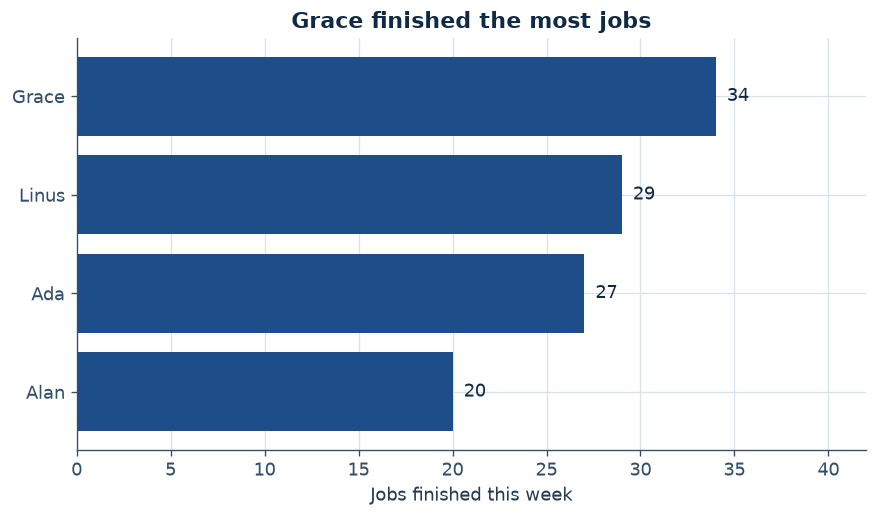

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Horizontal bars, sorted. The top bar is the answer to "who".
names = ["Alan", "Ada", "Linus", "Grace"]
totals = [20, 27, 29, 34]
fig, ax = plt.subplots(constrained_layout=True)
ax.barh(names, totals, color=BLUE)
ax.set_xlabel("Jobs finished this week")
ax.set_xlim(0, 42)
ax.set_title("Grace finished the most jobs")
for row, total in enumerate(totals):
    ax.text(total + 0.6, row, str(total), va="center", color=INK)
assert names[-1] == "Grace" and totals[-1] == max(totals)


## Did the lab speed up?

The question is about change across an ordered week. The mark is a point for each day, joined because Monday really does come before Tuesday. The sentence is already in the arithmetic: the line rises by $2$ jobs every day.


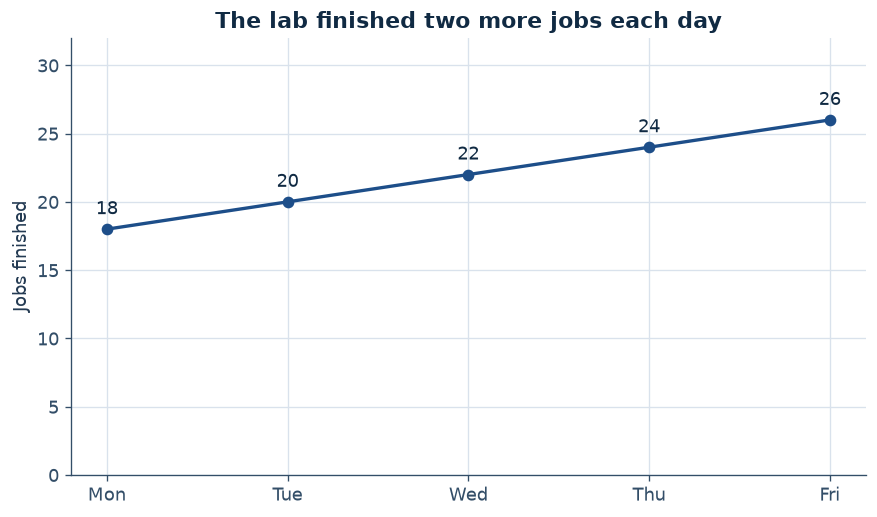

In [3]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# A line is allowed because the x-axis is time in order.
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
totals = [18, 20, 22, 24, 26]
fig, ax = plt.subplots(constrained_layout=True)
ax.plot(days, totals, color=BLUE, marker="o", linewidth=2)
ax.set_ylabel("Jobs finished")
ax.set_ylim(0, 32)
ax.set_title("The lab finished two more jobs each day")
for day, total in zip(days, totals):
    ax.text(day, total + 1.1, str(total), ha="center", color=INK)


## A pitfall

The same four weekly totals, drawn as a line through Ada, Grace, Alan, and Linus, invent a crash at Alan. Alan is a person, not a time. Nothing "fell" between Grace and Alan. The line is joining names the table never ordered.

## What to carry forward

Ask the question first. Compute the number. Choose length for a comparison of names, and a line for change across time. Then say the sentence out loud. Here the sentences are "Grace finished the most" and "the lab added two jobs a day."


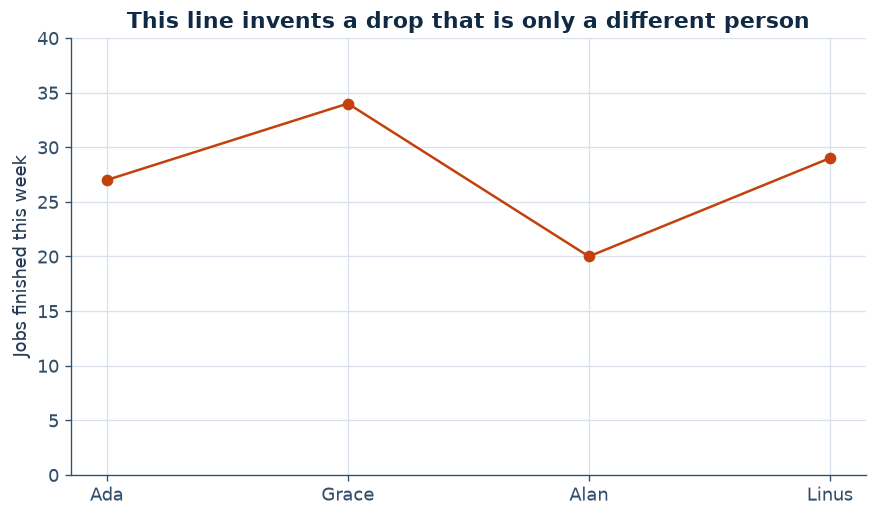

In [4]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Wrong encoding: a line through names pretends the names are a sequence.
fig, ax = plt.subplots(constrained_layout=True)
ax.plot(["Ada", "Grace", "Alan", "Linus"], [27, 34, 20, 29], marker="o", color=CLAY)
ax.set_ylabel("Jobs finished this week")
ax.set_ylim(0, 40)
ax.set_title("This line invents a drop that is only a different person")
